### collect data

In [1]:
# import module
import gwosc
from gwosc.datasets import event_gps, find_datasets
from gwpy.timeseries import TimeSeries
import gwpy
from pycbc.waveform import get_td_waveform
import pylab
from matplotlib import pyplot as plt
from gwpy.plot import Plot
from gwpy.signal import filter_design
import numpy as np
from gwosc.api import fetch_event_json
import h5py
from pycbc import inference

/home/val/anaconda3/lib/python3.12/site-packages/gwpy/time/__init__.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import LIGOTimeGPS


In [236]:
# Event name
name_event = 'GW150914'

# Get the GPS time for the event
gps = event_gps(name_event)

# segment of time to get around the GPS time
segment = (int(gps)-4, int(gps)+4)

In [237]:
# collect data online
try:
    hdata = TimeSeries.fetch_open_data('H1', *segment, cache=True)
except:
    hdata = None
    print('No data from H1')

try:
    ldata = TimeSeries.fetch_open_data('L1', *segment, cache=True)
except:
    ldata = None
    print('No data from L1')

try:
    vdata = TimeSeries.fetch_open_data('V1', *segment, cache=True)
except:
    vdata = None
    print('No data from V1')
try:
    gdata = TimeSeries.fetch_open_data('G1', *segment, cache=True)
except:
    gdata = None
    print('No data from G1')

No data from V1
No data from G1


In [238]:
available_data = []

# Check if each data array contains values and add it to the list if it does
try:
    if hdata[0] != 'nan':
        available_data.append(hdata)
except:
    print('No data from H1')

try:
    if ldata[0] != 'nan':
        available_data.append(ldata)
except:
    print('No data from L1')

try:
    if vdata[0] != 'nan':
        available_data.append(vdata)
except:
    print('No data from V1')
    
try:
    if gdata[0] != 'nan':
        available_data.append(gdata)
except:
    print('No data from G1')

No data from V1
No data from G1


### plot raw waveform

### Q-graph

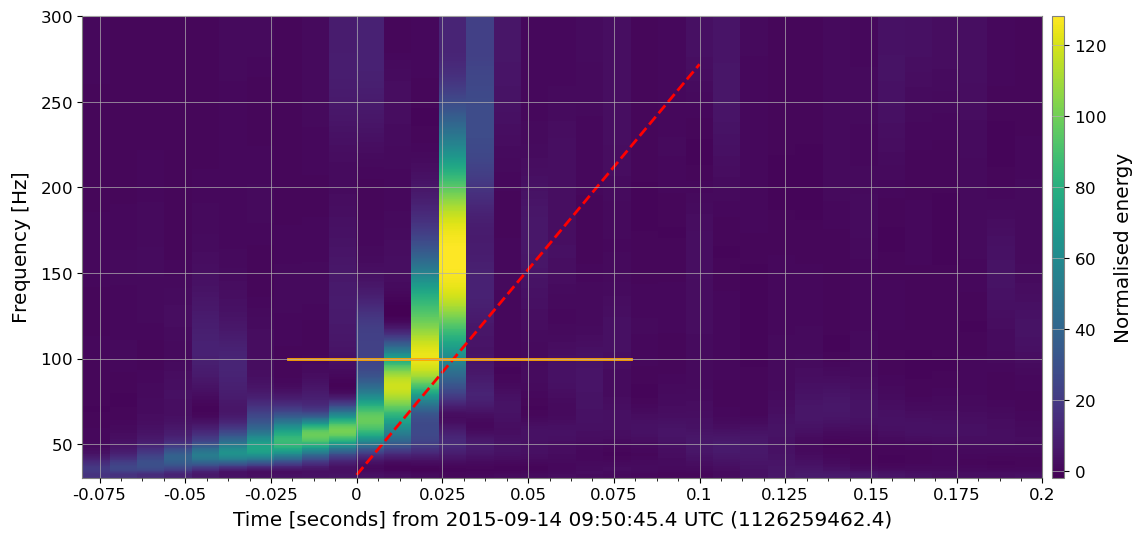

In [333]:
# Generate the Q-transform plot
q = available_data[0].q_transform(frange=(30, 300), qrange=(5, 100))
plot1 = q.plot()
ax1 = plot1.gca()

# Set plot parameters
ax1.set_epoch(gps)
#ax1.set_yscale('log')
ax1.set_xlim(gps-0.08, gps+0.20)
ax1.colorbar(label="Normalised energy")

# Define a line to overlay (example: an exponential fit or a simple line)
# Here, time is relative to `gps`
time = np.linspace(gps-0.02, gps + 0.08, 100)
freq = 2400*(time-gps) + 80

x = np.linspace(100, 100, 100)
# Overlay the line on the plot
ax1.plot(time+0.02, freq, color='red', linestyle='--', linewidth=2, label="Fitted line")
ax1.plot(time,x, color='orange', linestyle='-', linewidth=2)

# Add legend and show the plot
plt.show()

In [334]:
print(freq[0], freq[-1])
print(time[0]-gps)

32.00004577636719 271.99981689453125
-0.019999980926513672


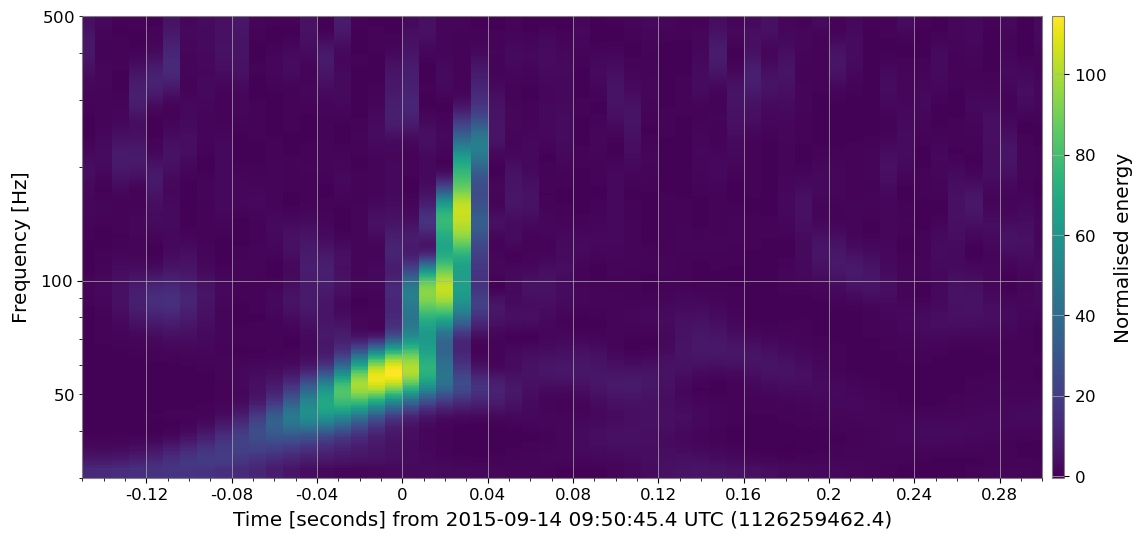

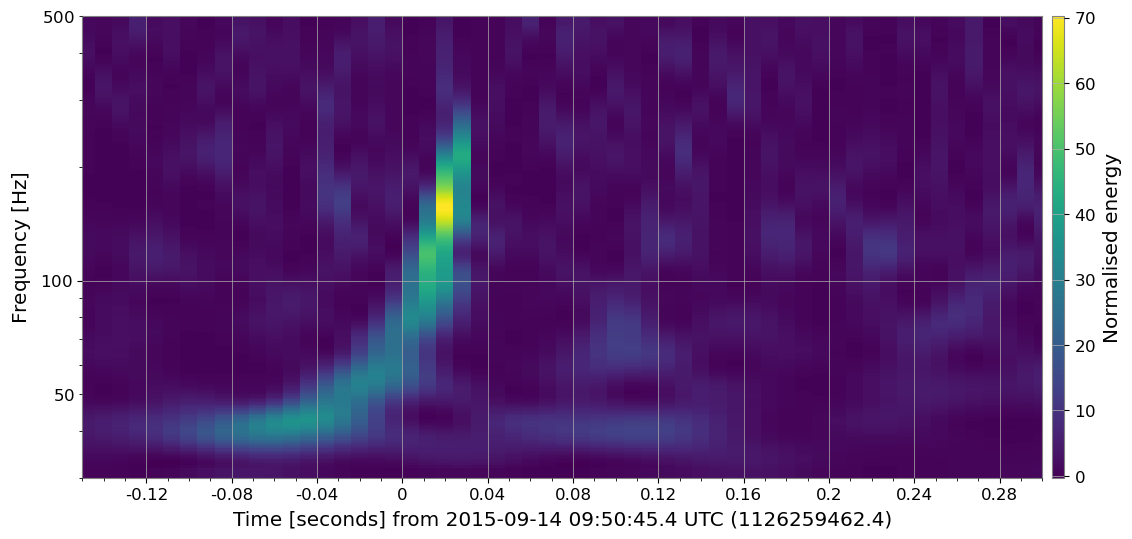

In [301]:
# tranform the data to get Q-graph and observe it easily 
for i in range(0,len(available_data)):
    q = available_data[i].q_transform(frange=(30, 500), qrange=(10,10)) # frange is the frequency range (y-axis)
    # q range could stretch the data horizontally and vertically (not sure)
    plot1 = q.plot()
    ax1 = plot1.gca()
    ax1.set_epoch(gps)
    ax1.set_yscale('log')
    ax1.set_xlim(gps-0.15, gps+0.3)
    ax1.colorbar(label="Normalised energy")
    plt.show()

### process the data

In [154]:
# generate bandpass, which remove low and high freq 
low_freq = 30
high_freq = 140
bp = filter_design.bandpass(flow=low_freq, fhigh=high_freq, sample_rate=available_data[0].sample_rate)

In [155]:
# create notch filters for first 3 harmonics of the 60 Hz AC mains power
notches = [filter_design.notch(line, available_data[0].sample_rate) for
           line in (60, 120, 180)]

In [156]:
# concatenate the filters to create a single ZPK
zpk = filter_design.concatenate_zpks(bp, *notches)

In [157]:
# apply zpk to the data
datafilt1 = available_data[0].filter(zpk, filtfilt=True)

In [158]:
# remove the data corrupted from the previous method (not that important since it is mainly on the ends)
data = datafilt1.crop(*available_data[0].span.contract(1))
filt = datafilt1.crop(*available_data[0].span.contract(1))

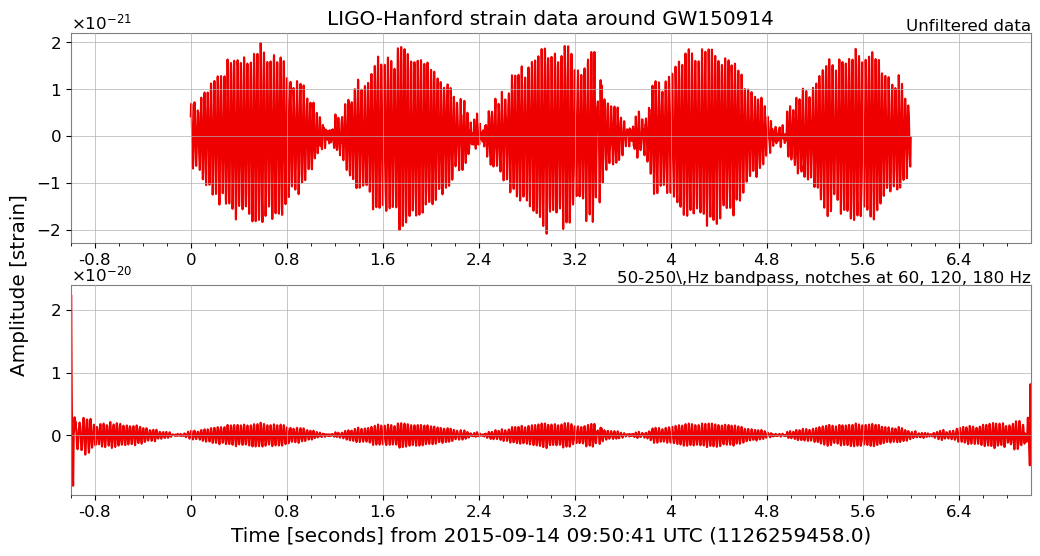

In [263]:
# plot raw and filtered data
plot = Plot(data, datafilt1, figsize=[12, 6], separate=True, sharex=True,
            color='gwpy:ligo-hanford')
ax1, ax2 = plot.axes
ax1.set_title(f'LIGO-Hanford strain data around {name_event}')
ax1.text(1.0, 1.01, 'Unfiltered data', transform=ax1.transAxes, ha='right')
ax1.set_ylabel('Amplitude [strain]', y=-0.2)
ax2.set_ylabel('')
ax2.text(1.0, 1.01, r'50-250\,Hz bandpass, notches at 60, 120, 180 Hz',
         transform=ax2.transAxes, ha='right')
plot.show()

In [159]:
# filter Second rawdata
try:
    datafilt2 = available_data[1].filter(zpk, filtfilt=True)
except:
    print('No data')

In [160]:
# filter Third rawdata
try:
    datafilt3 = available_data[2].filter(zpk, filtfilt=True)
except:
    print('No data')

In [161]:
# filter Fourth rawdata
try:
    datafilt4 = available_data[3].filter(zpk, filtfilt=True)
except:
    print('No data')

### Plot waveforms

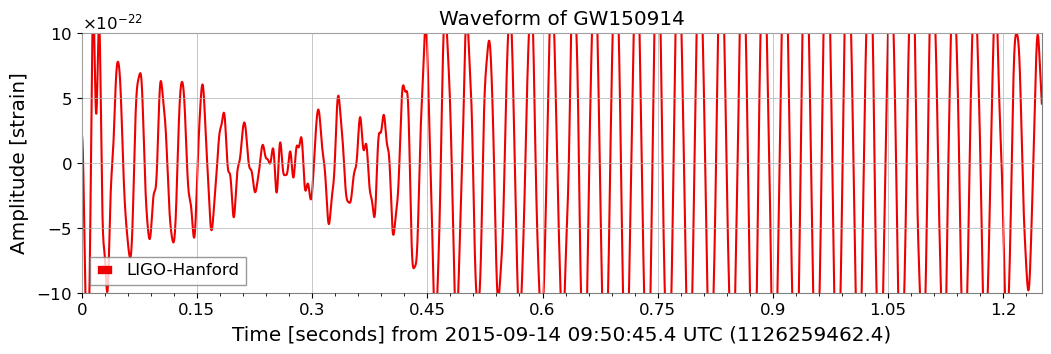

In [308]:
# get waveforms
plot = Plot(figsize=[12, 4])
ax = plot.gca()
# plot 1st data
ax.plot(datafilt1, label='LIGO-Hanford', color='gwpy:ligo-hanford')
# plot 2nd data
#try:
#    ax.plot(datafilt2, label='LIGO-Livingston', color='gwpy:ligo-livingston')
#except:
#    pass
# plot 3rd data
#try:
#    ax.plot(datafilt3, label='VIrgo', color='gwpy:virgo')
#except:
#    pass
# plot 4th data
#try:
#    ax.plot(datafilt4, label='GE600', color='gwpy:geo')
#except:
#    pass
ax.set_title(f'Waveform of {name_event}')
ax.set_xlim(gps-0, gps+1.25)
ax.set_xscale('seconds', epoch=gps)
ax.set_ylabel('Amplitude [strain]')
ax.set_ylim(-1e-21, 1e-21)
ax.legend()
plot.show()


### Get distance from most recent database

In [316]:
# Find all datasets associated with the event name
datasets = find_datasets(type='event', detector=None, segment=segment)

# Find the newest dataset
if datasets:
    datasets.sort(reverse=True)  # Sort by string, to get newest first

    # Get the newest version of the event
    newest_event_name = datasets[0]

    # Get event parameters
    event_data = fetch_event_json(newest_event_name)

    # Extract distance and uncertainties from the event data
    distance = event_data['events'][newest_event_name].get('luminosity_distance')
    distance_lower = event_data['events'][newest_event_name].get('luminosity_distance_lower')
    distance_upper = event_data['events'][newest_event_name].get('luminosity_distance_upper')
    
    # Extract masses and uncertainties from event data
    mass1 = event_data['events'][newest_event_name].get('mass_1_source')
    mass1_lower = event_data['events'][newest_event_name].get('mass_1_source_lower')
    mass1_upper = event_data['events'][newest_event_name].get('mass_1_source_upper')
    
    mass2 = event_data['events'][newest_event_name].get('mass_2_source')
    mass2_lower = event_data['events'][newest_event_name].get('mass_2_source_lower')
    mass2_upper = event_data['events'][newest_event_name].get('mass_2_source_upper')

    if distance is not None:
        print(f"Distance to {newest_event_name}: {distance} Mpc")
        print(f"Uncertainty: {distance_lower} Mpc, +{distance_upper} Mpc")
        print('')
    else:
        print(f"No distance data available for {newest_event_name}")
        print('')
        
    if mass1 is not None:
        print(f"mass 1 of {newest_event_name}: {mass1} M_Sun")
        print(f"Uncertainty: {mass1_lower} M_Sun, +{mass1_upper} M_Sun")
        print('')
    else:
        print(f"No mass 1 data available for {newest_event_name}")
        print('')
        
    if mass2 is not None:
        print(f"mass 2 of {newest_event_name}: {mass2} M_Sun")
        print(f"Uncertainty: {mass2_lower} M_Sun, +{mass2_upper} M_Sun")
        print('')
    else:
        print(f"No mass 2 data available for {newest_event_name}")
        print('')
else:
    print(f"Could not find a dataset for event: {name_event}")

Distance to GW150914-v3: 440.0 Mpc
Uncertainty: -170.0 Mpc, +150.0 Mpc

mass 1 of GW150914-v3: 35.6 M_Sun
Uncertainty: -3.1 M_Sun, +4.7 M_Sun

mass 2 of GW150914-v3: 30.6 M_Sun
Uncertainty: -4.4 M_Sun, +3.0 M_Sun



### Calculate low distance

In [325]:
from gwpy.timeseries import TimeSeries
from gwpy.astro import inspiral_range

D_range = []

for i in range(len(available_data)):
    hoff = available_data[i].psd(fftlength=4)
    r = inspiral_range(hoff, fmin=30, mass1=mass1, mass2=mass2)

    SNR_threshold = 8. # set arbitrarly
    SNR_measured = event_data['events'][newest_event_name].get('network_matched_filter_snr')
    D_range.append(r * SNR_threshold/SNR_measured)

In [326]:
low_distance = np.mean([d.value for d in D_range])
print(low_distance)

281.01629517065976


### Calculate high distance

In [342]:
datafilt1 = hdata.crop(gps-2,gps+2)
asd = datafilt1.asd(fftlength=2)  # Adjust FFT length as needed

# Get the value at 100 Hz
closest_freq_index = (abs(asd.frequencies.value - 100)).argmin()
strain_at_100hz = asd.value[closest_freq_index]
print(strain_at_100hz)

1.1947909603522366e-23


In [321]:
M_chirp = (mass1 * mass2)**(3/5) / (mass1 + mass2)**(1/5)
print(M_chirp)

28.71648348924461


In [346]:
f_gw = 100. # chosen frequency 
fdot_gw = 272/0.019 # frequency/time for chosen frequency
h100 = strain_at_100hz # strain for chosen frequency

In [344]:
# numerical constants
c = 299792458 # m/s
G = 6.67408e-11 # MKS
Msun = 1.98847e30 # kg
Mpc = 3.086e22 # m

# estimate chirp mass from f, fdot
chirptime = ( (5./96.) * fdot_gw * f_gw**(-11./3.) * np.pi**(-8./3.) )**(3./5.)
chirpmass = chirptime * (c**3) /G 

print('M_chirp = '+ str(chirpmass/Msun) +' Msun')

M_chirp = 68.48891809789569 Msun


In [345]:
# estimate distance from data (this is the effective distance)
D = (4.*c/h100)*(5./96.)*(1./np.pi**2)*fdot_gw*f_gw**-3

print('D = '+ str(D/Mpc) +' Mpc')

D = 246690.33805841435 Mpc


### Calculate distance

In [91]:
low_freq = 20

In [92]:
# get a list of all the available parameters and urls for this event
strain_data = event_data['events'][newest_event_name].get('strain')
# List of detectors
detectors = ['G1', 'V1', 'H1', 'L1']

# Filter URLs for sampling rate 4096 and duration 32
filtered_urls = []
for file_info in strain_data:
    if file_info['sampling_rate'] == 4096 and file_info['duration'] == 32 and file_info['format'] == 'gwf':
        if any(detector in file_info['detector'] for detector in detectors):
            filtered_urls.append(file_info['url'])

In [93]:
# assign available urls to data
gdata = hdata = ldata = vdata = None
for url in filtered_urls:
    if "G-G1" in url:
        gdata = url
    elif "H-H1" in url:
        hdata = url
    elif "L-L1" in url:
        ldata = url
    elif "V-V1" in url:
        vdata = url

In [94]:
from pycbc.catalog import Merger
from pycbc.psd import interpolate, inverse_spectrum_truncation
from pycbc.frame import read_frame
from pycbc.filter import highpass, resample_to_delta_t
from astropy.utils.data import download_file

url_map = {'V1': vdata, 'G1': gdata, 'H1': hdata, 'L1': ldata}

# Initialise dictionaries for storing data
data_filenames = {}
psds = {}
data = {}

# Loop through each detector to get url
for detector in detectors:
    print(f"Processing {detector} data")
    
    # Get the url for available detector
    url = url_map.get(detector)
    
    # Check if url is None
    if url is None:
        print(f"No URL available for {detector}")
        continue

    # Download the file
    fname = download_file(url, cache=True)
    data_filenames[detector] = fname

    # Load the time series data for 4 seconds before and after the event
    ts = read_frame(fname, f"{detector}:GWOSC-4KHZ_R1_STRAIN",
                    start_time=int(gps - 4),
                    end_time=int(gps + 4))
    
    # Preprocess the data: high-pass filter, resample, and convert to frequency series
    ts = highpass(ts, low_freq)                       # Remove low-frequency content
    ts = resample_to_delta_t(ts, 1.0 / 2048)          # Resample to 2048 Hz
    data[detector] = ts.to_frequencyseries()          # Convert to frequency series
    
    # Estimate and process the power spectral density (PSD)
    psd = interpolate(ts.psd(4), ts.delta_f)
    psd = inverse_spectrum_truncation(psd, int(4 * psd.sample_rate), 
                                      trunc_method='hann', 
                                      low_frequency_cutoff=low_freq)
    psds[detector] = psd

Processing G1 data
Processing V1 data
Processing H1 data
Processing L1 data


In [95]:
from pycbc.inference import models, sampler
from pycbc.distributions import Uniform, JointDistribution, SinAngle
import copy
from pycbc.inference.sampler import emcee_pt
approximant = 'IMRPhenomXPHM'


In [96]:
# configure model file
model_config = f"""
[model]
name = single_template
low-frequency-cutoff = {low_freq}.
"""

!echo '{model_config}' > model.ini
!cat model.ini


[model]
name = single_template
low-frequency-cutoff = 20.



In [97]:
# Get only detectors that have data
available_detectors = {detector: path for detector, path in data_filenames.items() if path}

# Prepare the instruments and frame-files strings based on available detectors
instruments = ' '.join(available_detectors.keys())
frame_files = ' '.join(f"{det}:{path}" for det, path in available_detectors.items())
channels = ' '.join(f"{det}:GWOSC-4KHZ_R1_STRAIN" for det in available_detectors.keys())

# Create the data configuration
data_config = f"""
[data]
instruments = {instruments}
trigger-time = {gps}
analysis-start-time = -4
analysis-end-time = 4
psd-estimation = median
psd-start-time = -4
psd-end-time = 4
psd-segment-length = 4
psd-segment-stride = 2
psd-inverse-length = 4
strain-high-pass = {low_freq}
pad-data = 8
sample-rate = 2048
frame-files = {frame_files}
channel-name = {channels}
"""

!echo '{data_config}' > data.ini
!cat data.ini


[data]
instruments = G1 V1 H1 L1
trigger-time = 1187008882.4
analysis-start-time = -4
analysis-end-time = 4
psd-estimation = median
psd-start-time = -4
psd-end-time = 4
psd-segment-length = 4
psd-segment-stride = 2
psd-inverse-length = 4
strain-high-pass = 20
pad-data = 8
sample-rate = 2048
frame-files = G1:/home/val/.astropy/cache/download/url/07024045fc37d7142e306635767cfb8a/contents V1:/home/val/.astropy/cache/download/url/523c219cb59a7e56ef34f966231891c8/contents H1:/home/val/.astropy/cache/download/url/5561880fffdb3ae3383cfc160856b5fc/contents L1:/home/val/.astropy/cache/download/url/db3d2138dbcca88082a3dd15c36ac55e/contents
channel-name = G1:GWOSC-4KHZ_R1_STRAIN V1:GWOSC-4KHZ_R1_STRAIN H1:GWOSC-4KHZ_R1_STRAIN L1:GWOSC-4KHZ_R1_STRAIN



In [133]:
# create prior parameter file
prior_config = f"""
[variable_params]
distance =
inclination =
ra = 
dec =

[static_params]
mass1 = {mass1}
mass2 = {mass2}
f_lower = {low_freq}
approximant = {approximant}
polarization = 0
tc = {gps}

[prior-distance]
name = uniform
min-distance = {low_distance}
max-distance = {distance+distance_upper}

[prior-inclination]
name = sin_angle

[prior-ra+dec]
name = uniform_sky
"""
!echo '{prior_config}' > prior.ini
!cat prior.ini


[variable_params]
distance =
inclination =
ra = 
dec =

[static_params]
mass1 = 1.46
mass2 = 1.27
f_lower = 20
approximant = IMRPhenomXPHM
polarization = 0
tc = 1187008882.4

[prior-distance]
name = uniform
min-distance = 22.347478676749922
max-distance = 47.0

[prior-inclination]
name = sin_angle

[prior-ra+dec]
name = uniform_sky



In [ ]:
# create the sampler file
sampler_config = f"""
[sampler]
name = emcee_pt
ntemps = 6
nwalkers = 500
niterations = 600
"""

!echo '{sampler_config}' > sampler.ini
!cat sampler.ini

In [134]:
# run inference
!pycbc_inference --verbose \
    --config-files model.ini data.ini prior.ini sampler.ini \
    --output-file inference.hdf \
    --nprocesses 8 \
    --force    

2025-02-15T18:12:23.604+00:00 INFO : Using seed 0
2025-02-15T18:12:23.604+00:00 INFO : Running with CPU support: 1 threads
2025-02-15T18:12:23.605+00:00 INFO : Reading configuration file
2025-02-15T18:12:23.610+00:00 INFO : Setting up model
2025-02-15T18:12:23.614+00:00 INFO : Setting up priors for each parameter
2025-02-15T18:12:23.614+00:00 WARNING : No sampling_params section read from config file
2025-02-15T18:12:23.616+00:00 INFO : Determining analysis times to use
2025-02-15T18:12:23.617+00:00 INFO : Padding G1 analysis start and end times by 2 (= psd-inverse-length/2) seconds to account for PSD wrap around effects.
2025-02-15T18:12:23.617+00:00 INFO : Padding V1 analysis start and end times by 2 (= psd-inverse-length/2) seconds to account for PSD wrap around effects.
2025-02-15T18:12:23.617+00:00 INFO : Padding H1 analysis start and end times by 2 (= psd-inverse-length/2) seconds to account for PSD wrap around effects.
2025-02-15T18:12:23.617+00:00 INFO : Padding L1 analysis sta

In [135]:
# plot a corner plot of the results from inference 
!pycbc_inference_plot_posterior --input-file inference.hdf \
    --output-file posterior.png \
    --plot-contours --plot-marginal \
    --plot-scatter --plot-marginal --z-arg snr

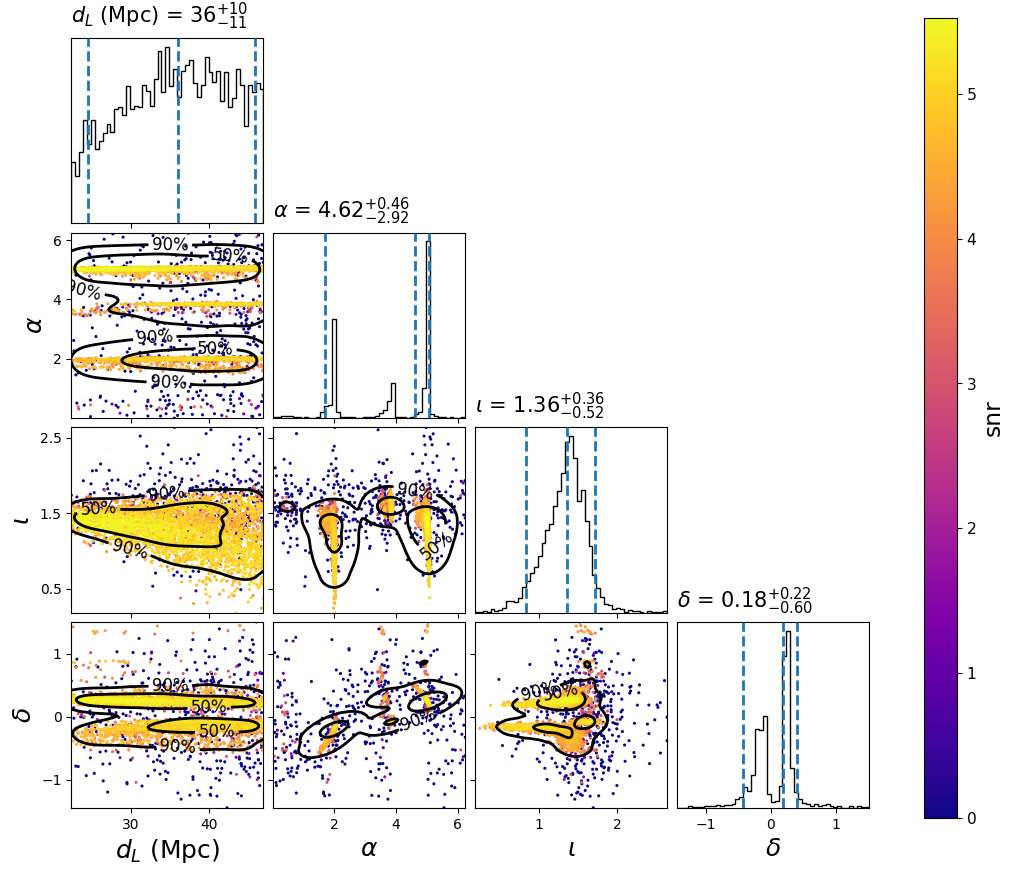

In [136]:
# plot the results for all posterior
from IPython.display import Image
Image('posterior.png', height=480)

In [137]:
# plot a density map of distance and inclination
!pycbc_inference_plot_posterior --input-file inference.hdf \
    --output-file posterior-dist_inc.png \
    --plot-density --plot-contours --plot-marginal \
    --parameters distance inclination 

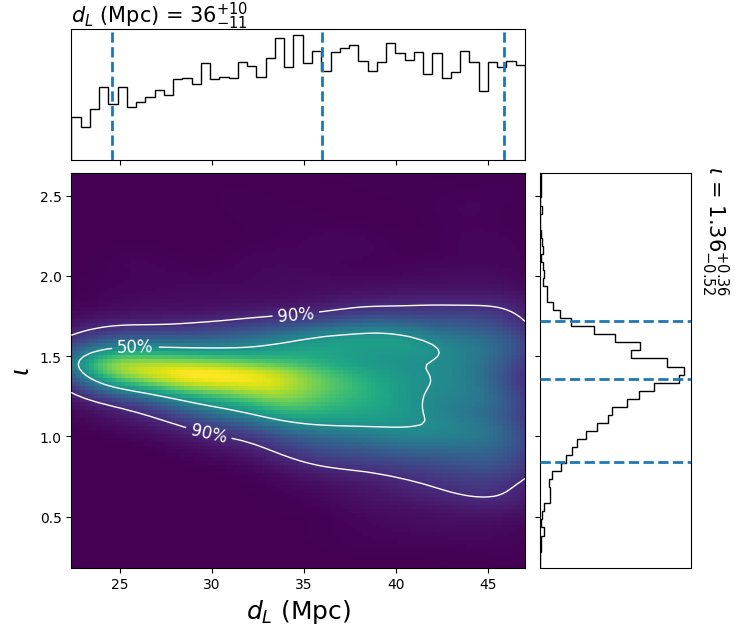

In [138]:
# Plot the result for distance and inclination
Image('posterior-dist_inc.png')

In [30]:
print(f'Distance of event is: {distance} Mpc')
print(f'Uncertainty: {distance_lower} Mpc, +{distance_upper} Mpc')

Distance of event is: 40.0 Mpc
Uncertainty: -15.0 Mpc, +7.0 Mpc


### simulate waveform

In [104]:
import pycbc

approximant = 'IMRPhenomXPHM'

# Generate the waveform
hp, hc = get_td_waveform(approximant=approximant,
                         mass1=mass1,
                         mass2=mass2,
                         delta_t=1/4096,
                        f_lower=low_freq,
                        distance=distance)

time_shift = hp.sample_times - gps - hp.start_time.gpsSeconds - 0.02
new_sample_times = hp.sample_times - time_shift

# Create a new TimeSeries object with the shifted sample times
hp_shifted = pycbc.types.TimeSeries(hp.data, delta_t=hp.delta_t, epoch=new_sample_times[0])

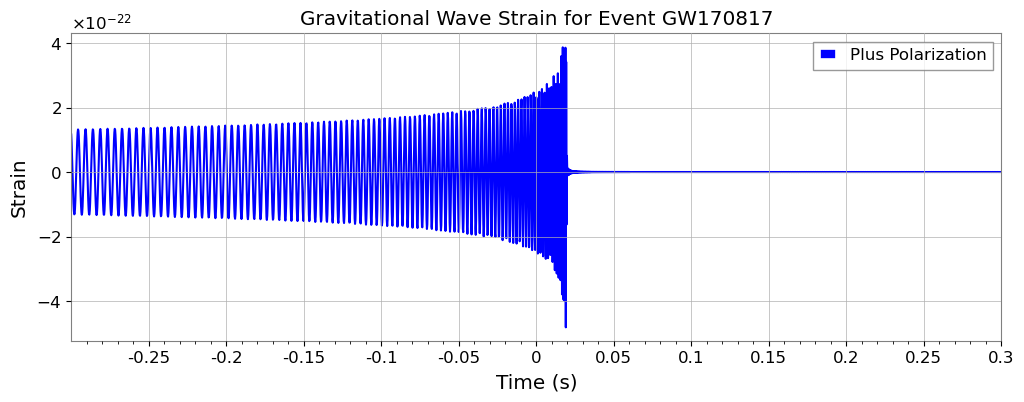

In [107]:
# Plotting the waveform and the strain data
fig, ax = plt.subplots(figsize=[12, 4])

# Plot the gravitational waveform
ax.plot(hp_shifted.sample_times, hp_shifted, label='Plus Polarization', color='blue')

# Plot the filtered data from LIGO-Hanford
#ax.plot(datafilt2, label='Data', color='red')

# Customize the plot
ax.set_xlabel('Time (s)')
ax.set_ylabel('Strain')
ax.set_title(f'Gravitational Wave Strain for Event {name_event}')
ax.set_xlim(gps-.3, gps+0.3)
ax.set_xscale('seconds', epoch=gps)
#ax.set_ylim(-1e-22, 1e-22)
ax.legend()

# Show the plot
plt.show()